In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from xgboost import XGBRegressor
import joblib


# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("/content/Indian_House_Prices.csv")


df.drop("Unnamed: 0", axis=1, inplace=True)

drop_cols = [
    "SportsFacility",
    "Intercom",
    "VaastuCompliant",
    "RainWaterHarvesting",
    "LandscapedGardens",
    "Gasconnection",
    "24X7Security",
    "Children'splayarea",
    "BED",
    "IndoorGames",
    "MaintenanceStaff",
    "MultipurposeRoom",
    "StaffQuarter",
    "Sofa",
    "TV",
    "Microwave",
    "Refrigerator",
    "DiningTable",
    "WashingMachine",
    "ATM",
    "School",
    "Hospital",
    "ShoppingMall",
    "GolfCourse",
    "Cafeteria"
]

df = df.drop(columns=drop_cols)




In [153]:
df.sample(10)

,Price,Area,Location,No. of Bedrooms,Resale,Gymnasium,SwimmingPool,JoggingTrack,ClubHouse,PowerBackup,CarParking,AC,Wifi,LiftAvailable,Wardrobe,City,Latitude,Longitude
4966,100.00,800,Kalkaji Extension,3.0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Delhi,28.529363,77.263073
2165,27.50,550,Irumbuliyur,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Chennai,12.912203,80.108898
5504,33.00,845,Chattarpur,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Delhi,28.497140,77.181251
8783,264.00,1014,Kandivali East,3.0,1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,Mumbai,19.210381,72.864084
2237,33.21,977,Singaperumal Koil,2.0,0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,Chennai,12.761204,80.004071
5619,125.00,1200,Sector 13 Rohini,3.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Delhi,28.722450,77.132173
7326,86.24,1670,Narsingi,3.0,0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,Hyderabad,18.019101,78.069271
1497,52.50,1250,Kudlu,2.0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,Banglore,12.888913,77.655572
6272,36.00,1050,Mehdipatnam,2.0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,17.394263,78.434251
5176,23.11,540,Uttam Nagar,2.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Delhi,28.619074,77.056686


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9390 entries, 0 to 9389
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Price            9390 non-null   float64
 1   Area             9390 non-null   int64  
 2   Location         9390 non-null   object 
 3   No. of Bedrooms  9390 non-null   float64
 4   Resale           9390 non-null   int64  
 5   Gymnasium        9390 non-null   float64
 6   SwimmingPool     9390 non-null   float64
 7   JoggingTrack     9390 non-null   float64
 8   ClubHouse        9390 non-null   float64
 9   PowerBackup      9390 non-null   float64
 10  CarParking       9390 non-null   float64
 11  AC               9390 non-null   float64
 12  Wifi             9390 non-null   float64
 13  LiftAvailable    9390 non-null   float64
 14  Wardrobe         9390 non-null   float64
 15  City             9390 non-null   object 
 16  Latitude         9390 non-null   float64
 17  Longitude     

In [138]:
df.duplicated().sum()

np.int64(1890)

In [139]:
df = df.drop_duplicates()

In [140]:
df.describe()


,Price,Area,No. of Bedrooms,Resale,Gymnasium,SwimmingPool,JoggingTrack,ClubHouse,PowerBackup,CarParking,AC,Wifi,LiftAvailable,Wardrobe,Latitude,Longitude
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.00000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,109.789473,1380.232400,2.494533,0.357200,0.519467,0.412267,0.328800,0.415600,0.659067,0.46680,0.071867,0.023467,0.718267,0.023733,19.055793,74.254710
std,139.292752,741.148681,0.768667,0.479206,0.499654,0.492276,0.469808,0.492858,0.474055,0.49893,0.258284,0.151390,0.449874,0.152227,7.767018,19.118199
min,20.000000,200.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,-28.816624,-117.147666
25%,45.807500,945.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,12.979240,77.036315
50%,72.000000,1230.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,17.451523,77.691611
75%,130.000000,1645.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.000000,0.000000,1.000000,0.000000,23.244199,79.922469
max,4000.000000,9900.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,65.447377,127.655678


In [141]:
df.describe(include='object')

,Location,City
count,7500,7500
unique,741,6
top,Kharghar,Hyderabad
freq,244,1730


<Axes: xlabel='Price', ylabel='Count'>

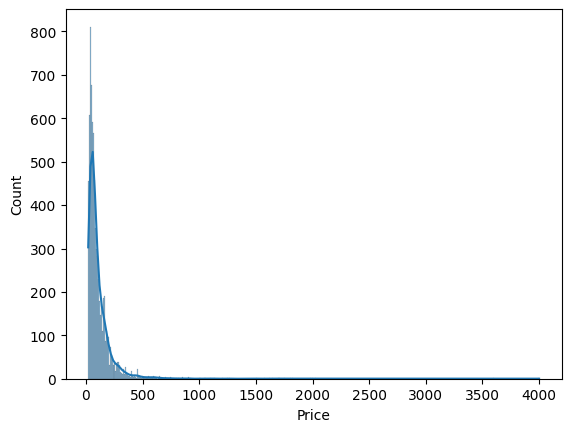

In [142]:
sns.histplot(df["Price"], kde=True)

<Axes: ylabel='Price'>

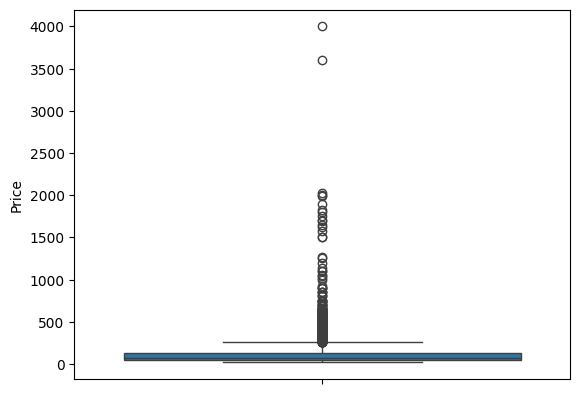

In [143]:
sns.boxplot(y=df["Price"])

<Axes: xlabel='City'>

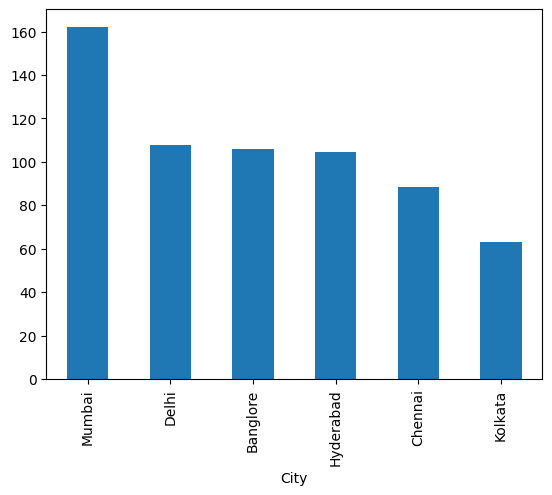

In [144]:
city_price = df.groupby("City")["Price"].mean().sort_values(ascending=False)
city_price.plot(kind="bar")

In [145]:
location_price = df.groupby("Location")["Price"].mean().sort_values(ascending=False)
location_price.head(20)

,Price
Location,
juhu tara,1800.000000
Tardeo,1350.000000
Worli,1147.222222
Mahalaxmi,1125.000000
Lower Parel,1105.666667
West End,1100.000000
Peddar Road,1000.000000
DLF Phase 5,892.500000
Richmond Town,887.000000


<Axes: xlabel='Area', ylabel='Price'>

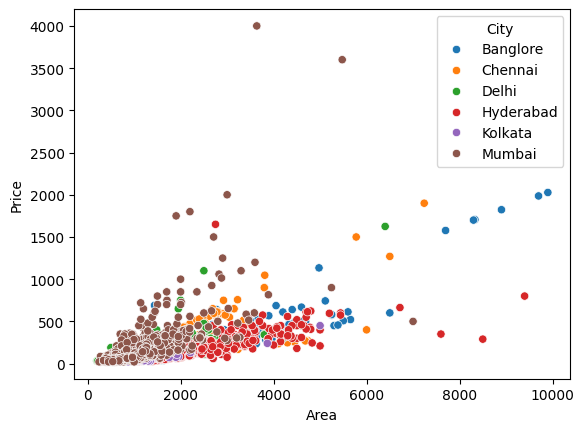

In [146]:
sns.scatterplot(
    x=df["Area"],
    y=df["Price"],hue=df["City"]

)

In [147]:
df.groupby(
    "No. of Bedrooms"
)["Price"].mean()

,Price
No. of Bedrooms,
1.0,49.307915
2.0,67.411748
3.0,125.543430
4.0,295.740120
5.0,806.864865
6.0,425.000000
8.0,575.000000


<Axes: xlabel='No. of Bedrooms', ylabel='Price'>

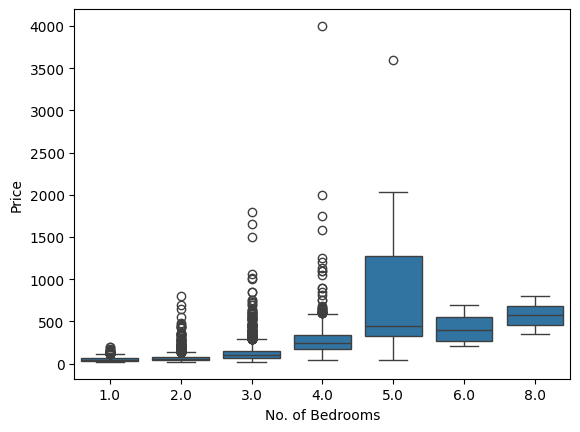

In [148]:
sns.boxplot(
    x=df["No. of Bedrooms"],
    y=df["Price"]
)

In [149]:
for col in [
    "Gymnasium",
    "SwimmingPool",
    "ClubHouse",
    "PowerBackup",
    "LiftAvailable"
]:
    print(
        df.groupby(col)["Price"].mean()
    )

Gymnasium
0.0     88.752480
1.0    129.249771
Name: Price, dtype: float64
SwimmingPool
0.0     91.114814
1.0    136.412338
Name: Price, dtype: float64
ClubHouse
0.0     90.441236
1.0    136.996185
Name: Price, dtype: float64
PowerBackup
0.0     79.094259
1.0    125.668021
Name: Price, dtype: float64
LiftAvailable
0.0     94.245116
1.0    115.886601
Name: Price, dtype: float64


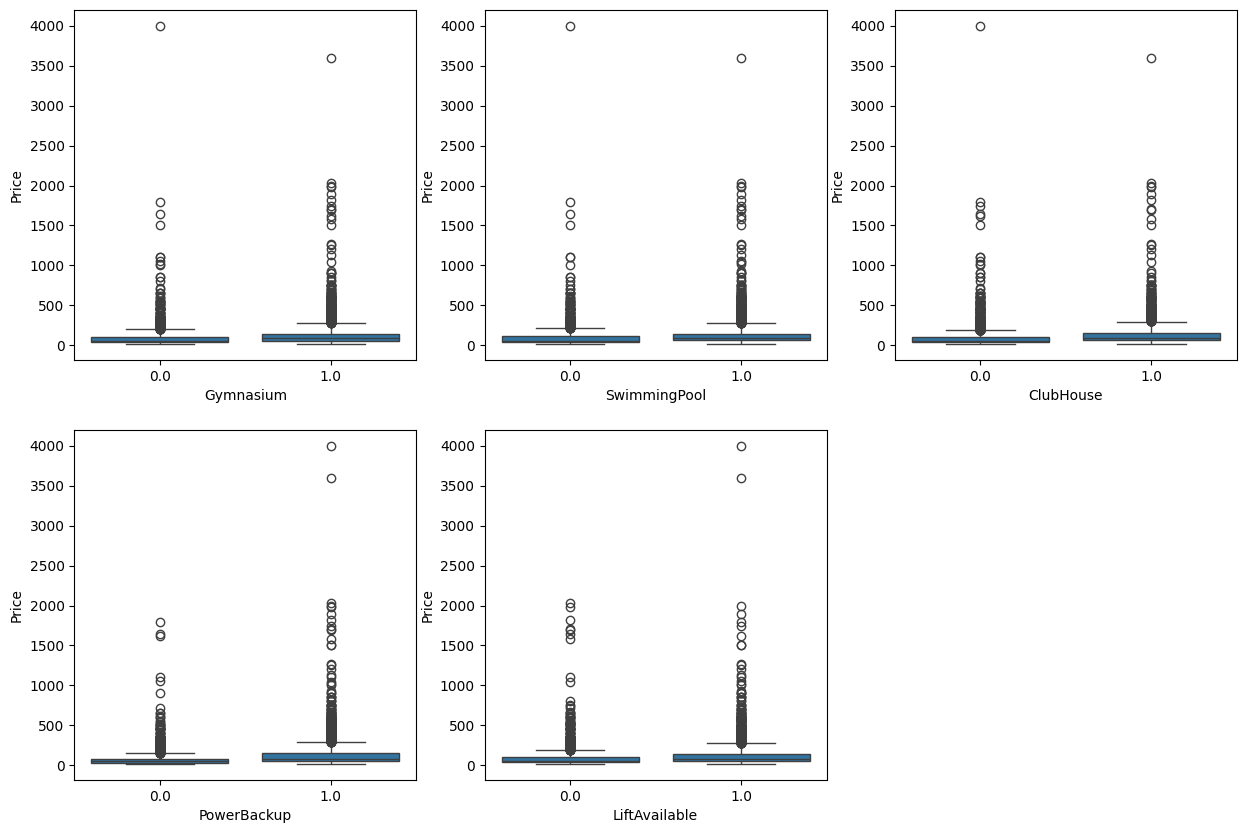

In [109]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(
    [
        "Gymnasium",
        "SwimmingPool",
        "ClubHouse",
        "PowerBackup",
        "LiftAvailable"
    ]
):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[col], y=df["Price"])



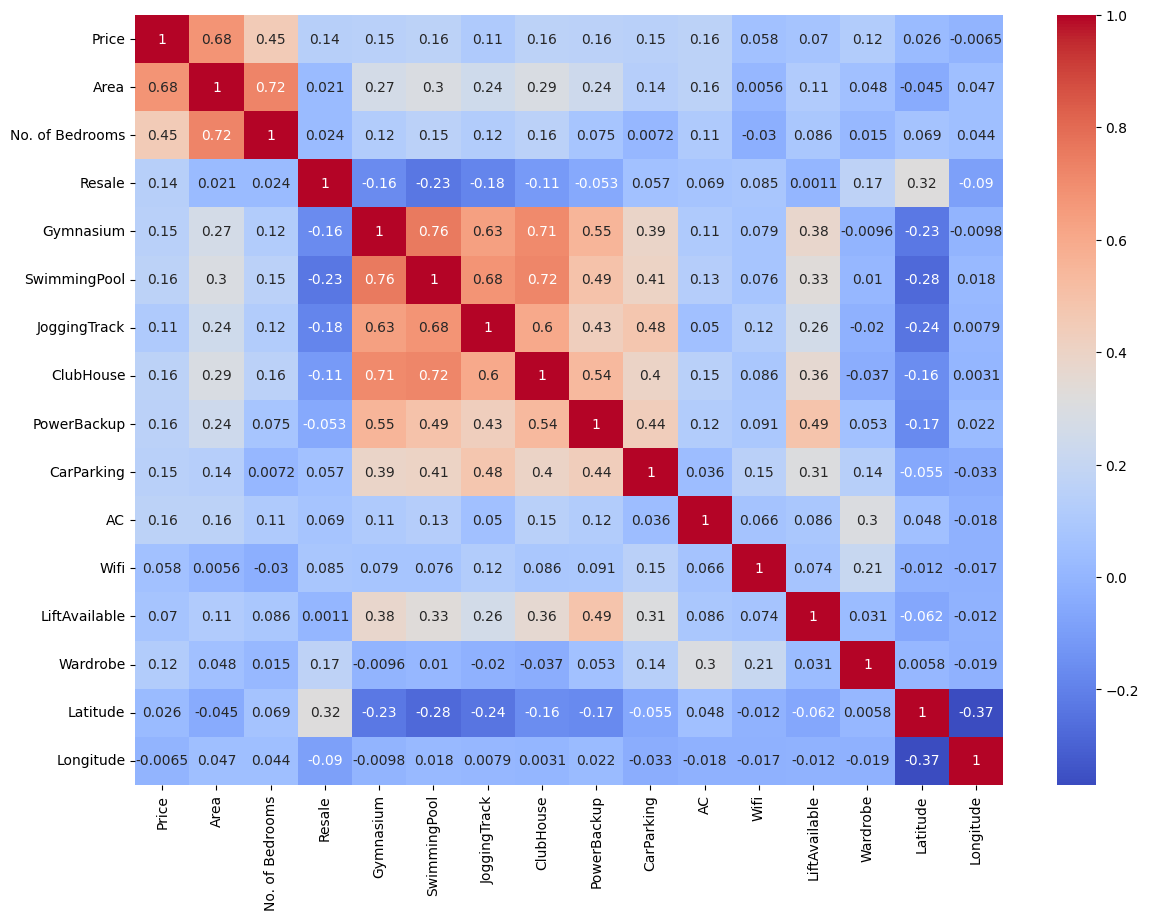

In [110]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [111]:
q01 = df["Price"].quantile(0.01)
q99 = df["Price"].quantile(0.99)

df = df[
    (df["Price"] >= q01) &
    (df["Price"] <= q99)
]

In [112]:
df["Price_log"] = np.log1p(df["Price"])

In [113]:
df["Area_per_Bedroom"] = (
    df["Area"] /
    df["No. of Bedrooms"]
)

In [114]:
df["Lat_Long"] = (
    df["Latitude"] *
    df["Longitude"]
)

In [115]:
df["Luxury_Score"] = (
    df["SwimmingPool"] +
    df["Gymnasium"] +
    df["ClubHouse"] +
    df["PowerBackup"] +
    df["LiftAvailable"]
)

In [116]:
X = df.drop(
    ["Price", "Price_log"],
    axis=1
)
y = df["Price_log"]

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [118]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

In [119]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score

In [120]:
numeric_col = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_col = ["City"]
target_col = ["Location"]

In [121]:
numeric_pipeline = Pipeline(steps= [
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

target_location_pipeline = Pipeline(steps = [
    ("encoder", TargetEncoder())
])

In [122]:
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_col),
    ("categorical", categorical_pipeline, categorical_col),
    ("target", target_location_pipeline, target_col)
])

In [123]:
model_xgbost = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    n_jobs=-1,
    random_state=42
)


In [124]:
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model_xgbost)
])



In [125]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print(cv_scores)
print(cv_scores.mean())

[0.89756956 0.89642292 0.89471028 0.89165862 0.91270563]
0.8986134019158236


In [126]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    KFold
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    "model__n_estimators": [300, 500, 800, 1000],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.2, 0.3]
}

random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    cv=kf,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [127]:
random_search.fit(
    X_train,
    y_train
)

y_pred = random_search.predict(X_test)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'model__subsample': 0.7, 'model__n_estimators': 1000, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.7}
Best Score: 0.9102789876406666


In [128]:
from lightgbm import LGBMRegressor

In [129]:
model_lgm  = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)

lgbm_pipline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model_lgm)
])

param_grid_lgbm = {
    "model__n_estimators": [300,500,800,1000],
    "model__learning_rate": [0.01,0.03,0.05,0.1],
    "model__max_depth": [3,5,7,10,-1],
    "model__num_leaves": [15,31,50,70,100],
    "model__min_child_samples": [10,20,30,50],
    "model__subsample": [0.7,0.8,0.9,1.0],
    "model__colsample_bytree": [0.7,0.8,0.9,1.0],
    "model__min_split_gain": [0,0.01,0.05,0.1]
}

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_pipline,
    param_distributions=param_grid_lgbm,
    n_iter=30,
    cv=kf,
    scoring="r2",
    random_state=42,
    verbose=2
)

random_search_lgbm.fit(
    X_train,
    y_train
)

y_pred = random_search_lgbm.predict(X_test)




Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.7, model__learning_rate=0.05, model__max_depth=7, model__min_child_samples=20, model__min_split_gain=0.01, model__n_estimators=500, model__num_leaves=70, model__subsample=1.0; total time=   0.9s


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.7, model__learning_rate=0.05, model__max_depth=7, model__min_child_samples=20, model__min_split_gain=0.01, model__n_estimators=500, model__num_leaves=70, model__subsample=1.0; total time=   0.3s


...

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=7, model__min_child_samples=10, model__min_split_gain=0.05, model__n_estimators=500, model__num_leaves=31, model__subsample=1.0; total time=   0.7s


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=7, model__min_child_samples=10, model__min_split_gain=0.05, model__n_estimators=500, model__num_leaves=31, model__subsample=1.0; total time=   0.8s


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [130]:
print("Best Parameters:", random_search_lgbm.best_params_)
print("Best Score:", random_search_lgbm.best_score_)

Best Parameters: {'model__subsample': 0.9, 'model__num_leaves': 70, 'model__n_estimators': 1000, 'model__min_split_gain': 0, 'model__min_child_samples': 10, 'model__max_depth': -1, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
Best Score: 0.9062723667097943


In [131]:
best_lgbm = random_search_lgbm.best_estimator_

y_pred_log = best_lgbm.predict(X_test)

r2_log = r2_score(y_test, y_pred_log)

print("Log R2:", r2_log)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Log R2: 0.9125932034631845


In [132]:
best_model = random_search_lgbm.best_estimator_

joblib.dump(
    best_model,
    "house_price_pipeline.pkl"
)

['house_price_pipeline.pkl']

In [133]:
city_location_mapping = {}

for city in df["City"].unique():
    city_location_mapping[city] = sorted(
        df[df["City"] == city]["Location"].unique().tolist()
    )

joblib.dump(
    city_location_mapping,
    "city_location_mapping.pkl"
)

['city_location_mapping.pkl']

In [134]:
best_lgbm.named_steps["model"].feature_importances_
feature_names = (
    best_lgbm.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_lgbm.named_steps["model"].feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(30))

                        feature  importance
0                 numeric__Area       12916
15    numeric__Area_per_Bedroom       12847
24             target__Location        8469
14           numeric__Longitude        7766
13            numeric__Latitude        6768
16            numeric__Lat_Long        5527
17        numeric__Luxury_Score        3330
8           numeric__CarParking        1493
2               numeric__Resale        1384
11       numeric__LiftAvailable        1282
1      numeric__No. of Bedrooms        1115
5         numeric__JoggingTrack         893
7          numeric__PowerBackup         823
3            numeric__Gymnasium         761
6            numeric__ClubHouse         751
21  categorical__City_Hyderabad         598
4         numeric__SwimmingPool         588
9                   numeric__AC         557
23     categorical__City_Mumbai         330
10                numeric__Wifi         188
12            numeric__Wardrobe         176
19    categorical__City_Chennai 

In [150]:
location_lat_long = (
    df.groupby("Location")[["Latitude", "Longitude"]]
    .mean()
    .round(6)
    .to_dict("index")
)

joblib.dump(
    location_lat_long,
    "location_lat_long.pkl"
)

['location_lat_long.pkl']